In [1]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from lifelines import CoxPHFitter
import seaborn as sns

In [2]:
from utils.load_data import load_target_dataset
from utils.clinical_data_features import extract_cytogenetic_features, add_severity_features
from utils.molecular_data_features import process_molecular_data_effect, classify_impact

In [3]:
target_df = load_target_dataset("./target_train.csv")

# Clinical Data
df = pd.read_csv("X_train/clinical_train.csv")
df_eval = pd.read_csv("X_test/clinical_test.csv")

# Extract some features from chromosomes to both training and test sets
df = extract_cytogenetic_features(df)
df_eval = extract_cytogenetic_features(df_eval)

# Apply to both training and test sets
df = add_severity_features(df)
df_eval = add_severity_features(df_eval)

#df.drop(columns=["abnormal_cell_proportion"], inplace=True)
#df_eval.drop(columns=["abnormal_cell_proportion"], inplace=True)
df.drop(columns=['CYTOGENETICS'], inplace=True)
df_eval.drop(columns=['CYTOGENETICS'], inplace=True)

df_mol = pd.read_csv("X_train/molecular_train.csv")
df_eval_mol = pd.read_csv("X_test/molecular_test.csv")

df_mol['EFFECT_LEVEL'] = df_mol['EFFECT'].apply(classify_impact)
df_eval_mol['EFFECT_LEVEL'] = df_eval_mol['EFFECT'].apply(classify_impact)

# Process the molecular data for both training and evaluation sets
df_mol_processed = process_molecular_data_effect(df_mol)
df_eval_mol_processed = process_molecular_data_effect(df_eval_mol)

#We merge the processed molecular data with the clinical data
df = df.merge(df_mol_processed, on='ID', how='left')
#We fill NaN values with 0 for the new features
df.fillna(0, inplace=True)
df_eval = df_eval.merge(df_eval_mol_processed, on='ID', how='left')
#We fill NaN values with 0 for the new features
df_eval.fillna(0, inplace=True)

df.columns.to_series().to_csv("features.csv", index=False)

#We allign the rows of the df with the target_df
df = df[df['ID'].isin(target_df['ID'])]

#We drop the ID column as it is not needed anymore
df.drop(columns=['ID', 'CENTER'], inplace=True)
df_eval.drop(columns=['ID', 'CENTER'], inplace=True)
target_df = target_df.drop(columns=['ID'])

# Now split
X_train, X_test, y_train, y_test = train_test_split(df, target_df, test_size=0.3, random_state=42)
from sksurv.util import Surv
y_train_struct = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', y_train)
y_test_struct = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', y_test)

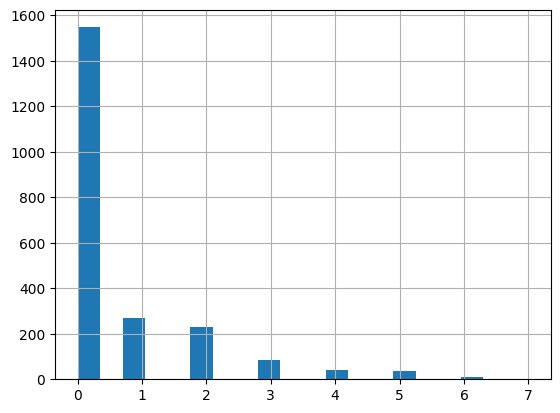

In [4]:
# Exemple : dataframe df, colonne 'age'
X_train['total_abnormalities'].hist(bins=20)
plt.show()

In [5]:
df_cox = pd.concat([df, target_df], axis=1)
#target_df = target_df[''].astype(int)

# Initialiser le modèle
cph = CoxPHFitter()

# Ajuster le modèle sur toutes les colonnes sauf 'temps_survie' et 'decede' comme features
cph.fit(df_cox, duration_col = 'OS_YEARS', event_col='OS_STATUS')

# Afficher le résumé
cph.print_summary()


/opt/homebrew/lib/python3.11/site-packages/lifelines/utils/__init__.py:1100: ConvergenceWarning: Column(s) ['is_normal'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)
/opt/homebrew/lib/python3.11/site-packages/lifelines/utils/__init__.py:797: RuntimeWarning: invalid value encountered in divide
  return (X - mean) / std


ConvergenceError: Convergence halted due to matrix inversion problems. Suspicion is high collinearity. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-modelMatrix is singular.

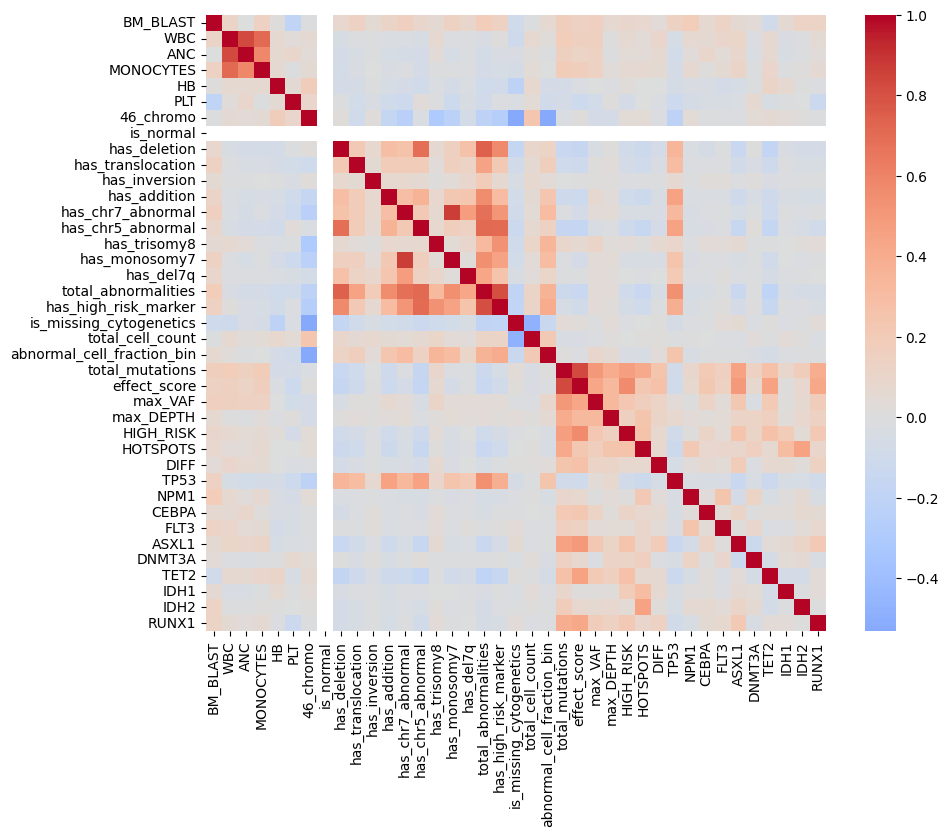

In [6]:
corr = df_cox.drop(columns=["OS_YEARS","OS_STATUS"]).corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.show()